# SAD - Modelo Preditivo de Tempo de Execução

Objetivo: treinar um modelo que prevê o tempo de execução de uma OS
antes da atribuição, substituindo a média histórica simples no motor de score.

**Abordagem:**
1. Regressão Linear - baseline interpretável
2. Random Forest - captura padrões não-lineares

**Target:** tempo_segundos (tempo real de execução)  
**Features:** tipo de OS, quantidade de itens, volume, hora do dia, operador

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
from urllib.parse import quote_plus
from pathlib import Path

# ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

load_dotenv(Path("..") / ".env")
db_password = quote_plus(os.getenv("DB_PASSWORD"))

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{db_password}@"
    f"{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print("Conexão OK")

Conexão OK


## 1. Preparação dos dados

Vamos extrair as features relevantes das execuções históricas.
Cada linha será uma execução finalizada com seus atributos e o tempo real.

In [3]:
df = pd.read_sql("""
    SELECT
        ex.id                           AS execucao_id,
        ex.operador_id,
        ex.tempo_segundos,
        os.tipo_codigo,
        ot.descricao                    AS tipo_os,
        EXTRACT(HOUR FROM ex.inicio)    AS hora_inicio,
        EXTRACT(DOW  FROM ex.inicio)    AS dia_semana,
        ex.itens_pendentes_inicio       AS qtd_itens,
        COALESCE(SUM(p.volume_cm3 * oi.qt_total), 0) AS volume_total_cm3,
        COALESCE(SUM(p.peso_bruto_kg * oi.qt_total), 0) AS peso_total_kg
    FROM execucoes ex
    JOIN os          ON os.id  = ex.os_id
    JOIN os_tipos ot ON ot.codigo = os.tipo_codigo
    JOIN os_itens oi ON oi.os_id  = ex.os_id
    JOIN produtos p  ON p.id   = oi.produto_id
    WHERE ex.status = 'finalizada'
      AND ex.tempo_segundos BETWEEN 60 AND 7200
    GROUP BY
        ex.id, ex.operador_id, ex.tempo_segundos,
        os.tipo_codigo, ot.descricao,
        ex.inicio, ex.itens_pendentes_inicio
    ORDER BY ex.id
""", engine)

print(f"Registros: {len(df)}")
print(f"Colunas: {list(df.columns)}")
df.head()

Registros: 580
Colunas: ['execucao_id', 'operador_id', 'tempo_segundos', 'tipo_codigo', 'tipo_os', 'hora_inicio', 'dia_semana', 'qtd_itens', 'volume_total_cm3', 'peso_total_kg']


,execucao_id,operador_id,tempo_segundos,tipo_codigo,tipo_os,hora_inicio,dia_semana,qtd_itens,volume_total_cm3,peso_total_kg
0,3,11,2314,9,Separação Paletizado Caixa Fechada,10.0,4.0,6,7097266.98,3154.206
1,8,29,1218,88,Armazenagem de Produtos,15.0,3.0,6,3088984.09,909.104
2,9,16,1067,9,Separação Paletizado Caixa Fechada,17.0,5.0,6,7538768.89,1038.104
3,10,26,1356,9,Separação Paletizado Caixa Fechada,8.0,4.0,12,7790555.27,2465.814
4,11,48,1474,88,Armazenagem de Produtos,14.0,3.0,10,12398282.91,1873.669


## 2. Análise das features

Antes de treinar qualquer modelo, precisamos entender a relação
entre cada feature e o tempo de execução.

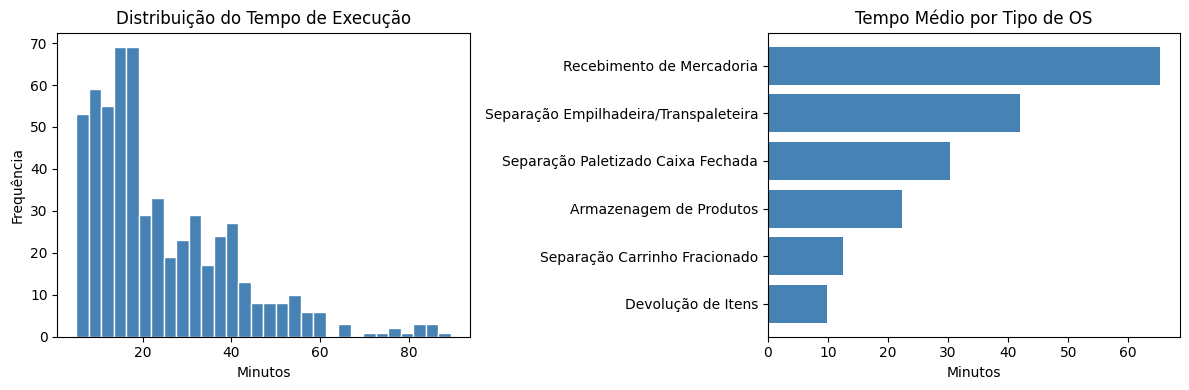


Estatísticas do target:
count    580.0
mean      24.0
std       16.1
min        5.0
25%       12.5
50%       18.3
75%       32.9
max       89.4
Name: tempo_segundos, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribuição do tempo
axes[0].hist(df['tempo_segundos'] / 60, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição do Tempo de Execução')
axes[0].set_xlabel('Minutos')
axes[0].set_ylabel('Frequência')

# Tempo médio por tipo de OS
tempo_tipo = df.groupby('tipo_os')['tempo_segundos'].mean().sort_values() / 60
axes[1].barh(tempo_tipo.index, tempo_tipo.values, color='steelblue')
axes[1].set_title('Tempo Médio por Tipo de OS')
axes[1].set_xlabel('Minutos')

plt.tight_layout()
plt.show()

print("\nEstatísticas do target:")
print((df['tempo_segundos'] / 60).describe().round(1))

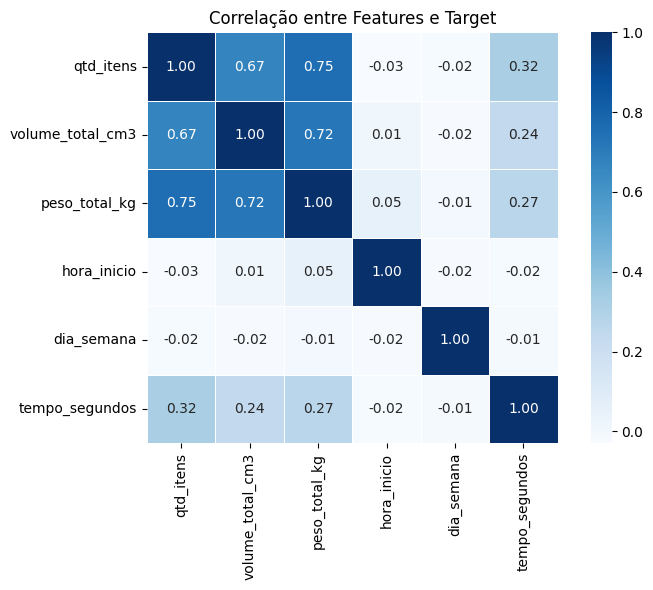

In [5]:
features_numericas = ['qtd_itens', 'volume_total_cm3', 'peso_total_kg', 
                       'hora_inicio', 'dia_semana', 'tempo_segundos']

corr = df[features_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', 
            square=True, linewidths=0.5)
plt.title('Correlação entre Features e Target')
plt.tight_layout()
plt.show()

## 3. Preparação para o modelo

Convertemos variáveis categóricas em numéricas e separamos
features (X) do target (y).

In [6]:
# Codifica tipo_os como número
le = LabelEncoder()
df['tipo_os_encoded'] = le.fit_transform(df['tipo_os'])

# Mapeamento para referência
print("Codificação de tipos de OS:")
for i, tipo in enumerate(le.classes_):
    print(f"  {i} → {tipo}")

# Define features e target
FEATURES = [
    'tipo_os_encoded',
    'qtd_itens',
    'volume_total_cm3',
    'peso_total_kg',
    'hora_inicio',
    'dia_semana',
    'operador_id'
]

X = df[FEATURES].fillna(0)
y = df['tempo_segundos']

print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")

# Divide em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTreino: {len(X_train)} registros")
print(f"Teste:  {len(X_test)} registros")

Codificação de tipos de OS:
  0 → Armazenagem de Produtos
  1 → Devolução de Itens
  2 → Recebimento de Mercadoria
  3 → Separação Carrinho Fracionado
  4 → Separação Empilhadeira/Transpaleteira
  5 → Separação Paletizado Caixa Fechada

Shape X: (580, 7)
Shape y: (580,)

Treino: 464 registros
Teste:  116 registros


## 4. Baseline — Regressão Linear

O modelo mais simples possível. Assume que a relação entre
as features e o tempo é linear.

Serve como ponto de comparação — se o Random Forest não
for significativamente melhor, a complexidade extra não vale.

In [7]:
# Treina o modelo
lr = LinearRegression()
lr.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred_lr = lr.predict(X_test)

# Métricas
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr   = r2_score(y_test, y_pred_lr)

print("--- REGRESSÃO LINEAR ---")
print(f"MAE  (erro médio absoluto): {mae_lr:.0f}s = {mae_lr/60:.1f} min")
print(f"RMSE (raiz do erro quadrático): {rmse_lr:.0f}s = {rmse_lr/60:.1f} min")
print(f"R²   (variância explicada): {r2_lr:.3f}")

print("\nInterpretação dos coeficientes:")
for feat, coef in zip(FEATURES, lr.coef_):
    print(f"  {feat:<25} {coef:+.2f}s por unidade")

--- REGRESSÃO LINEAR ---
MAE  (erro médio absoluto): 675s = 11.3 min
RMSE (raiz do erro quadrático): 864s = 14.4 min
R²   (variância explicada): 0.317

Interpretação dos coeficientes:
  tipo_os_encoded           +154.19s por unidade
  qtd_itens                 +72.69s por unidade
  volume_total_cm3          +0.00s por unidade
  peso_total_kg             +0.09s por unidade
  hora_inicio               -4.31s por unidade
  dia_semana                +0.71s por unidade
  operador_id               +27.15s por unidade


## 5. Random Forest

Conjunto de árvores de decisão que captura relações não-lineares
e interações entre features.

Deve performar melhor que a regressão linear, especialmente
em dados com padrões complexos.

In [8]:
rf = RandomForestRegressor(
    n_estimators=100,   # 100 árvores
    max_depth=10,       # profundidade máxima de cada árvore
    random_state=42,
    n_jobs=-1           # usa todos os núcleos disponíveis
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf   = r2_score(y_test, y_pred_rf)

print("--- RANDOM FOREST ---")
print(f"MAE  (erro médio absoluto):     {mae_rf:.0f}s = {mae_rf/60:.1f} min")
print(f"RMSE (raiz do erro quadrático): {rmse_rf:.0f}s = {rmse_rf/60:.1f} min")
print(f"R²   (variância explicada):     {r2_rf:.3f}")

print("\n--- COMPARAÇÃO ---")
print(f"{'Métrica':<10} {'Linear':>12} {'Random Forest':>15} {'Melhora':>10}")
print("-" * 50)
print(f"{'MAE (min)':<10} {mae_lr/60:>12.1f} {mae_rf/60:>15.1f} {((mae_lr-mae_rf)/mae_lr*100):>9.1f}%")
print(f"{'RMSE (min)':<10} {rmse_lr/60:>12.1f} {rmse_rf/60:>15.1f} {((rmse_lr-rmse_rf)/rmse_lr*100):>9.1f}%")
print(f"{'R²':<10} {r2_lr:>12.3f} {r2_rf:>15.3f} {((r2_rf-r2_lr)/abs(r2_lr)*100):>9.1f}%")

--- RANDOM FOREST ---
MAE  (erro médio absoluto):     429s = 7.1 min
RMSE (raiz do erro quadrático): 558s = 9.3 min
R²   (variância explicada):     0.715

--- COMPARAÇÃO ---
Métrica          Linear   Random Forest    Melhora
--------------------------------------------------
MAE (min)          11.3             7.1      36.5%
RMSE (min)         14.4             9.3      35.4%
R²                0.317           0.715     125.8%


## 6. Importância das features

Quais variáveis o Random Forest considerou mais relevantes
para prever o tempo de execução?

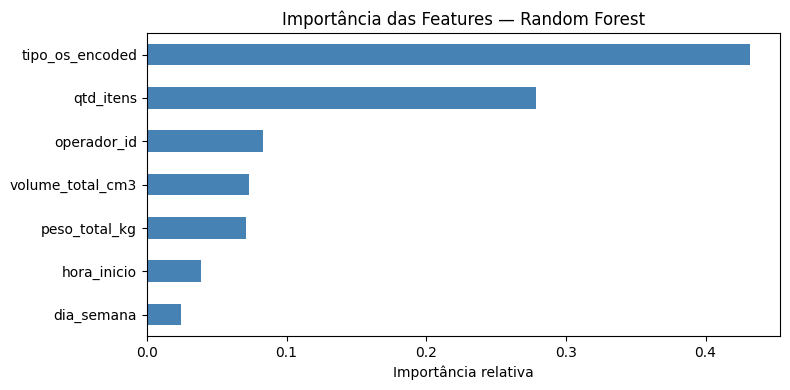


Importância por feature:
  tipo_os_encoded           0.432 (43.2%)
  qtd_itens                 0.278 (27.8%)
  operador_id               0.083 (8.3%)
  volume_total_cm3          0.073 (7.3%)
  peso_total_kg             0.071 (7.1%)
  hora_inicio               0.039 (3.9%)
  dia_semana                0.024 (2.4%)


In [9]:
importancias = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

plt.figure(figsize=(8, 4))
importancias.plot(kind='barh', color='steelblue')
plt.title('Importância das Features — Random Forest')
plt.xlabel('Importância relativa')
plt.tight_layout()
plt.show()

print("\nImportância por feature:")
for feat, imp in importancias.sort_values(ascending=False).items():
    print(f"  {feat:<25} {imp:.3f} ({imp*100:.1f}%)")

## 7. Visualização — Previsto vs Real

Compara graficamente o que o modelo previu com o que realmente aconteceu.
Um modelo perfeito teria todos os pontos na diagonal.

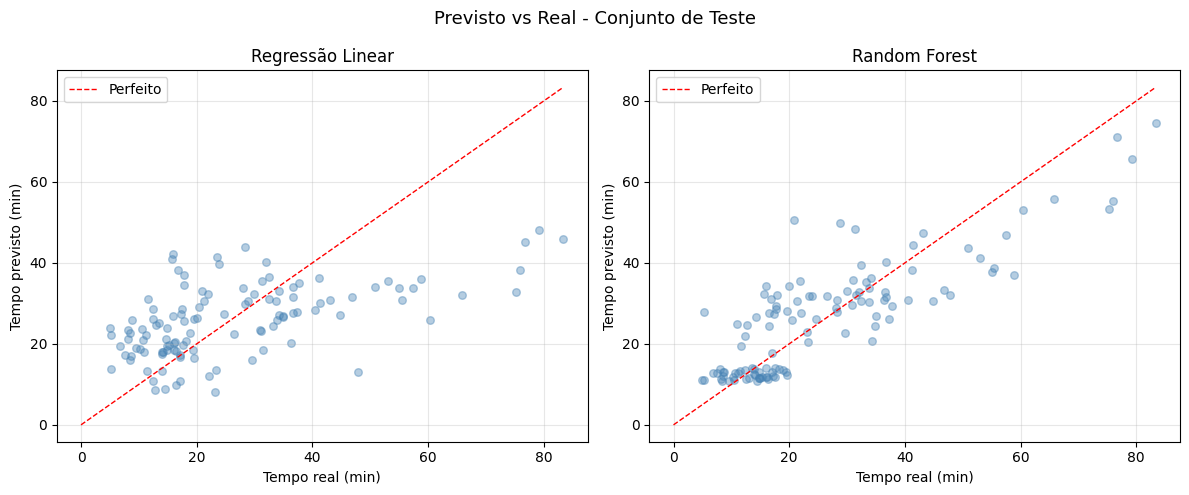

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, titulo in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Regressão Linear', 'Random Forest']
):
    ax.scatter(y_test / 60, y_pred / 60, alpha=0.4, s=30, color='steelblue')

    # Linha diagonal — previsão perfeita
    lim_max = max(y_test.max(), max(y_pred)) / 60
    ax.plot([0, lim_max], [0, lim_max], 'r--', linewidth=1, label='Perfeito')

    ax.set_xlabel('Tempo real (min)')
    ax.set_ylabel('Tempo previsto (min)')
    ax.set_title(titulo)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Previsto vs Real - Conjunto de Teste', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Salvar o modelo

Salvamos o modelo treinado e o encoder para uso na API.
O joblib serializa o objeto Python para disco - mais eficiente
que pickle para arrays numpy grandes como o Random Forest.

In [11]:
import joblib
from pathlib import Path

modelo_dir = Path("..") / "src" / "modelo"
modelo_dir.mkdir(exist_ok=True)

# Salva o modelo e o encoder
joblib.dump(rf, modelo_dir / "random_forest.joblib")
joblib.dump(le, modelo_dir / "label_encoder.joblib")

# Salva as features para garantir consistência na integração
joblib.dump(FEATURES, modelo_dir / "features.joblib")

print("Arquivos salvos:")
for f in modelo_dir.iterdir():
    print(f"  {f.name} ({f.stat().st_size / 1024:.1f} KB)")

Arquivos salvos:
  features.joblib (0.1 KB)
  label_encoder.joblib (0.6 KB)
  random_forest.joblib (2313.2 KB)


## 9. Conclusão

### Resultados

| Modelo | MAE | RMSE | R² |
|---|---|---|---|
| Regressão Linear | 11.3 min | 14.4 min | 0.317 |
| Random Forest | 7.1 min | 9.3 min | 0.715 |

O Random Forest foi **36.5% mais preciso** que a regressão linear e explica
71.5% da variação no tempo de execução.

### Features mais importantes
1. **Tipo de OS** (43.2%) - fator dominante, reflete diferenças estruturais entre operações
2. **Quantidade de itens** (27.8%) - relação direta com deslocamento e tempo
3. **Operador** (8.3%) - captura diferenças de performance individual
4. **Volume e peso** (~7% cada) - contribuição secundária

### Limitações

- **Dados sintéticos** - o tempo de execução foi gerado com aleatoriedade controlada,
  não descoberta organicamente. Parte da variação é ruído intencional que nenhum
  modelo consegue capturar.
- **hora_inicio e dia_semana** têm correlação ~0 nos dados sintéticos. Em dados reais
  refletiriam fadiga, turnos e variação de fluxo operacional.
- **operador_id como feature** - a matrícula é um identificador sem valor ordinal.
  O modelo captura variações aleatórias associadas a cada operador nos dados sintéticos.
  Em produção seria substituído por métricas reais como velocidade média histórica
  e taxa de finalização por tipo de OS; que o banco já registra em `execucoes`.
- Em dados reais o R² provavelmente chegaria a 85-90%.

### Escolha do modelo

Random Forest é a escolha adequada para dados tabulares estruturados com
poucas features. Modelos mais complexos como XGBoost ou redes neurais
trariam ganho marginal sem justificar a complexidade adicional para esse volume de dados.

### Próximo passo

Integrar a previsão do Random Forest no motor de score (`score.py`),
substituindo o `tempo_base` pela previsão do modelo quando disponível.